In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-08-13 04:26:25.404839: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-13 04:26:25.784042: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-08-13 04:26:30.828916: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
datasetPath = 'dataset/firstorder/kernel5/dataset.csv'

In [4]:
# Parameters
datasetPath = "dataset/glcm/kernel5/1.dataset.csv"


In [5]:
# train/validation/test = 70/10/20
dataset = pd.read_csv(datasetPath)

train_data, temp_data = train_test_split(dataset, test_size=0.3, random_state=42)
validation_data, test_data = train_test_split(temp_data, test_size=2/3, random_state=42)

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-08-13 04:26:44.913900: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-13 04:26:44.915816: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
import keras

In [8]:
%%time

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmpzhnfe22k as temporary training directory


Reading training dataset...


Training dataset read in 0:00:02.744265. Found 737 examples.


Training model...


Model trained in 0:00:00.068789


Compiling model...


[INFO 26-08-13 04:26:47.9129 UTC kernel.cc:1233] Loading model from path /tmp/tmpzhnfe22k/model/ with prefix 0125c58f4527442e
[INFO 26-08-13 04:26:47.9266 UTC decision_forest.cc:734] Model loaded with 300 root(s), 10350 node(s), and 24 input feature(s).
[INFO 26-08-13 04:26:47.9266 UTC abstract_model.cc:1362] Engine "RandomForestOptPred" built
[INFO 26-08-13 04:26:47.9266 UTC kernel.cc:1061] Use fast generic engine


Model compiled.


CPU times: user 5.75 s, sys: 121 ms, total: 5.87 s
Wall time: 6.19 s


In [9]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

1/1 [==============================] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9905

1/1 [==============================] - 3s 3s/step - loss: 0.0000e+00 - accuracy: 0.9905



loss: 0.0000
accuracy: 0.9905


In [10]:
# Model Summary
model.summary()

Model: "random_forest_model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


Total params: 1 (1.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 1 (1.00 Byte)


_________________________________________________________________


Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (24):
	Autocorrelation
	ClusterProminence
	ClusterShade
	ClusterTendency
	Contrast
	Correlation
	DifferenceAverage
	DifferenceEntropy
	DifferenceVariance
	Id
	Idm
	Idmn
	Idn
	Imc1
	Imc2
	InverseVariance
	JointAverage
	JointEnergy
	JointEntropy
	MCC
	MaximumProbability
	SumAverage
	SumEntropy
	SumSquares

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "Autocorrelation"  0.263105 ################
    2.       "JointAverage"  0.251201 #############
    3.         "SumAverage"  0.243535 ############
    4.               "Imc1"  0.202841 #####
    5.                "MCC"  0.196331 ####
    6.        "Correlation"  0.194135 ###
    7.    "InverseVariance"  0.192950 ###
    8. "MaximumProbability"  0.189321 ###
    9.                "Idm"  0.184019 ##
   10.               "Imc2"  0.180836 #
   11.                 "Id"  0.179658 #
   12.        "JointEnergy"  0.178804 #
   13.       "ClusterSh

In [11]:
# Model features
model.make_inspector().features()

["Autocorrelation" (1; #0),
 "ClusterProminence" (1; #1),
 "ClusterShade" (1; #2),
 "ClusterTendency" (1; #3),
 "Contrast" (1; #4),
 "Correlation" (1; #5),
 "DifferenceAverage" (1; #6),
 "DifferenceEntropy" (1; #7),
 "DifferenceVariance" (1; #8),
 "Id" (1; #9),
 "Idm" (1; #10),
 "Idmn" (1; #11),
 "Idn" (1; #12),
 "Imc1" (1; #13),
 "Imc2" (1; #14),
 "InverseVariance" (1; #15),
 "JointAverage" (1; #16),
 "JointEnergy" (1; #17),
 "JointEntropy" (1; #18),
 "MCC" (1; #19),
 "MaximumProbability" (1; #20),
 "SumAverage" (1; #21),
 "SumEntropy" (1; #22),
 "SumSquares" (1; #23)]

In [12]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Autocorrelation" (1; #0), 0.26310528774787423),
  ("JointAverage" (1; #16), 0.2512011502713501),
  ("SumAverage" (1; #21), 0.2435353366168989),
  ("Imc1" (1; #13), 0.2028405717181237),
  ("MCC" (1; #19), 0.1963314712820572),
  ("Correlation" (1; #5), 0.1941349062009465),
  ("InverseVariance" (1; #15), 0.19294993516417297),
  ("MaximumProbability" (1; #20), 0.18932131867427723),
  ("Idm" (1; #10), 0.1840191366334712),
  ("Imc2" (1; #14), 0.18083634353904718),
  ("Id" (1; #9), 0.17965750001340938),
  ("JointEnergy" (1; #17), 0.1788043441647163),
  ("ClusterShade" (1; #2), 0.17739689322427213),
  ("DifferenceEntropy" (1; #7), 0.17667663185196328),
  ("Idn" (1; #12), 0.1747107389979734),
  ("SumEntropy" (1; #22), 0.17382249186605184),
  ("DifferenceVariance" (1; #8), 0.17373043856922601),
  ("Idmn" (1; #11), 0.17319817601891782),
  ("DifferenceAverage" (1; #6), 0.1730168554858547),
  ("Contrast" (1; #4), 0.1722418692318439),
  ("JointEntropy" (1; #18), 0.172007295

In [13]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=737, accuracy=0.9130915535235469, loss=0.23247741553099946, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

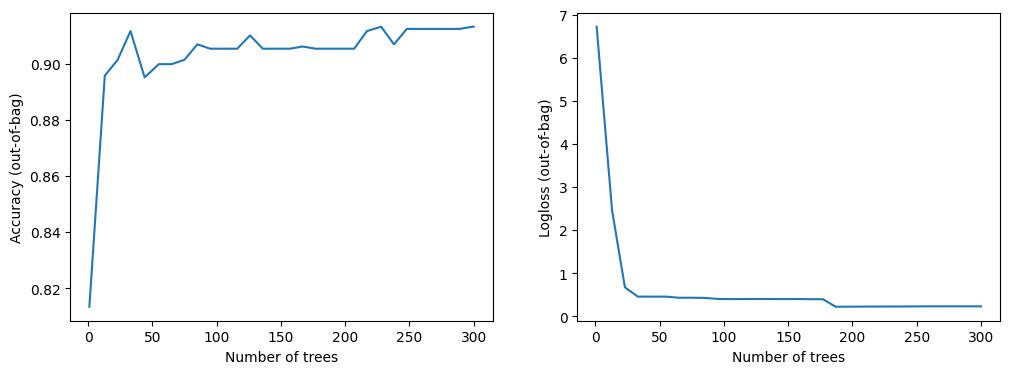

In [14]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 66ms/step


The ROC AUC score is 0.99372


In [16]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 79ms/step


Sklearn binary metrics:
accuracy: 0.9340
precision: 0.7895
recall: 0.8333
f1: 0.8108
mcc: 0.7713
roc_auc: 0.9770
pr_auc: 0.9009
log_loss: 0.1481
brier_score: 0.0461

Confusion matrix:
 [[168   8]
 [  6  30]]

Classification report:
               precision    recall  f1-score   support

           0     0.9655    0.9545    0.9600       176
           1     0.7895    0.8333    0.8108        36

    accuracy                         0.9340       212
   macro avg     0.8775    0.8939    0.8854       212
weighted avg     0.9356    0.9340    0.9347       212

